# Autoencoder anomaly detection with digits and letters

This notebook loads a **trained fully connected autoencoder** and uses it as a simple anomaly detector.
The key idea is that the model was trained on **MNIST digits only**, so it should usually reconstruct digits better than unfamiliar handwritten letters.


## What this notebook will do

We will go step by step:

1. Rebuild the same encoder and decoder architecture used during training.
2. Load the saved model weights from disk.
3. Load familiar MNIST digit images.
4. Load unfamiliar EMNIST letter images.
5. Reconstruct both kinds of images with the autoencoder.
6. Compare reconstruction losses and visualize the original and reconstructed images side by side.

This is a simple example of **anomaly detection by reconstruction error**.


In [28]:
# Import the libraries we need.
# torch is the main deep learning library.
# torchvision gives us image datasets and transforms.
# matplotlib is used for plotting.
# numpy helps with small numerical tasks.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms


In [29]:
# Choose the device.
# If a GPU is available, PyTorch can use it.
# Otherwise everything will run on the CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Selected device: {device}')

# This is the file written by the training notebook.
model_path = Path('saved_models/mnist_autoencoder_fc.pt')
print(f'Looking for saved model at: {model_path.resolve()}')


Selected device: cpu
Looking for saved model at: /Users/rolandg/Dropbox (Personal)/Lectures/2026/DataAnalysis_March2026/Notebooks/L9_JupyterNotebooks/saved_models/mnist_autoencoder_fc.pt


## Rebuild the trained autoencoder

To load saved weights, PyTorch needs the same model architecture that was used when the weights were created.
So we define the encoder and decoder classes again before loading the checkpoint file.


In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_size=28 * 28, hidden_size1=128, hidden_size2=16, z_dim=2):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.ReLU(),
            nn.Linear(hidden_size1, hidden_size2),
            nn.ReLU(),
            nn.Linear(hidden_size2, z_dim),
        )

    def forward(self, x):
        return self.linear_relu_stack(x)


class Decoder(nn.Module):
    def __init__(self, input_size=28 * 28, hidden_size1=128, hidden_size2=16, z_dim=2):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(z_dim, hidden_size2),
            nn.ReLU(),
            nn.Linear(hidden_size2, hidden_size1),
            nn.ReLU(),
            nn.Linear(hidden_size1, input_size),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.linear_relu_stack(z)


In [30]:
# Load the saved checkpoint from disk.
# map_location=device makes sure the file can be loaded on either CPU or GPU.
checkpoint = torch.load(model_path, map_location=device)

# Some saved files may come from an older version of the notebook.
# In that older version, the layer names were fc1, fc2, and fc3.
# In the cleaned-up notebook, the layers live inside linear_relu_stack.
# The helper functions below let us load either checkpoint format.
def convert_legacy_encoder_state_dict(state_dict):
    if 'fc1.weight' not in state_dict:
        return state_dict
    return {
        'linear_relu_stack.0.weight': state_dict['fc1.weight'],
        'linear_relu_stack.0.bias': state_dict['fc1.bias'],
        'linear_relu_stack.2.weight': state_dict['fc2.weight'],
        'linear_relu_stack.2.bias': state_dict['fc2.bias'],
        'linear_relu_stack.4.weight': state_dict['fc3.weight'],
        'linear_relu_stack.4.bias': state_dict['fc3.bias'],
    }


def convert_legacy_decoder_state_dict(state_dict):
    if 'fc1.weight' not in state_dict:
        return state_dict
    return {
        'linear_relu_stack.0.weight': state_dict['fc1.weight'],
        'linear_relu_stack.0.bias': state_dict['fc1.bias'],
        'linear_relu_stack.2.weight': state_dict['fc2.weight'],
        'linear_relu_stack.2.bias': state_dict['fc2.bias'],
        'linear_relu_stack.4.weight': state_dict['fc3.weight'],
        'linear_relu_stack.4.bias': state_dict['fc3.bias'],
    }


# Rebuild the encoder and decoder with the same sizes used during training.
# If the checkpoint does not store these values, fall back to the notebook defaults.
input_size = checkpoint.get('input_size', 28 * 28)
hidden_size1 = checkpoint.get('hidden_size1', 128)
hidden_size2 = checkpoint.get('hidden_size2', 16)
z_dim = checkpoint.get('z_dim', 2)

enc = Encoder(
    input_size=input_size,
    hidden_size1=hidden_size1,
    hidden_size2=hidden_size2,
    z_dim=z_dim,
).to(device)

dec = Decoder(
    input_size=input_size,
    hidden_size1=hidden_size1,
    hidden_size2=hidden_size2,
    z_dim=z_dim,
).to(device)

# Load the learned weights into the two networks.
encoder_state_dict = convert_legacy_encoder_state_dict(checkpoint['encoder_state_dict'])
decoder_state_dict = convert_legacy_decoder_state_dict(checkpoint['decoder_state_dict'])

enc.load_state_dict(encoder_state_dict)
dec.load_state_dict(decoder_state_dict)

# Switch both models to evaluation mode.
# This is the standard setting when we are using a trained network for inference only.
enc.eval()
dec.eval()

print('Saved model loaded successfully.')


Saved model loaded successfully.


## Load digit and letter images

We use two datasets:

- **MNIST** for handwritten digits, which match the training data
- **EMNIST Letters** for handwritten letters, which are unfamiliar to the model

Both datasets contain grayscale 28x28 images, which makes the comparison clean and fair.


In [31]:
# Convert each image to a tensor with values between 0 and 1.
transform = transforms.ToTensor()

# Load familiar digit images.
mnist_test = datasets.MNIST(root='dataset', train=False, download=True, transform=transform)

# Load unfamiliar letter images.
# EMNIST Letters uses labels 1 through 26 for A through Z.
emnist_letters = datasets.EMNIST(root='dataset', split='letters', train=False, download=True, transform=transform)

print(f'MNIST test images: {len(mnist_test)}')
print(f'EMNIST letter images: {len(emnist_letters)}')


MNIST test images: 10000
EMNIST letter images: 20800


In [32]:
# Helper function: convert the EMNIST label number into a capital letter.
def emnist_label_to_letter(label):
    return chr(ord('A') + label - 1)


# Helper function: collect a small batch of examples from a dataset.
# We keep the images and also build readable text labels for plotting.
# An optional image_transform lets us fix orientation issues before scoring.
def collect_examples(dataset, indices, label_formatter, image_transform=None):
    images = []
    text_labels = []

    for index in indices:
        image, label = dataset[index]
        if image_transform is not None:
            image = image_transform(image)
        images.append(image)
        text_labels.append(label_formatter(label))

    return torch.stack(images), text_labels


# Pick a few familiar digits and a few unfamiliar letters.
# These fixed indices make the notebook repeatable.
digit_indices = [0, 1, 2, 3, 4, 5]
letter_indices = [0, 1, 2, 3, 4, 5]

digit_images, digit_text_labels = collect_examples(
    mnist_test,
    digit_indices,
    label_formatter=lambda label: f'Digit {label}',
)

letter_images, letter_text_labels = collect_examples(
    emnist_letters,
    letter_indices,
    label_formatter=lambda label: f'Letter {emnist_label_to_letter(label)}',
    image_transform=lambda image: torch.flip(torch.rot90(image, k=-1, dims=(1, 2)), dims=(2,)),
)

print(digit_text_labels)
print(letter_text_labels)


['Digit 7', 'Digit 2', 'Digit 1', 'Digit 0', 'Digit 4', 'Digit 1']
['Letter A', 'Letter A', 'Letter A', 'Letter A', 'Letter A', 'Letter A']


## Reconstruct images and measure loss

The reconstruction loss tells us how different the output image is from the input image.
A lower loss means the autoencoder reconstructed the image more faithfully.

Because the model was trained on digits, we expect:

- lower loss for many digit images
- higher loss for many letter images


In [33]:
# Use mean squared error as the reconstruction loss.
# reduction="none" keeps the per-pixel errors so we can average them per image ourselves.
loss_fn = nn.MSELoss(reduction='none')


# This function runs the autoencoder on a batch of images.
# It returns the reconstructed images and one loss value per image.
def reconstruct_and_score(images):
    images = images.to(device)

    with torch.no_grad():
        flat_images = images.flatten(1)
        latent_vectors = enc(flat_images)
        reconstructed_flat = dec(latent_vectors)
        reconstructed_images = reconstructed_flat.view(-1, 1, 28, 28)

        pixel_losses = loss_fn(reconstructed_images, images)
        sample_losses = pixel_losses.view(images.size(0), -1).mean(dim=1)

    return images.cpu(), reconstructed_images.cpu(), sample_losses.cpu()


# This helper computes reconstruction losses for many images from a dataset.
# We use it to compare whole loss distributions, not just a few hand-picked examples.
def collect_loss_distribution(dataset, indices, batch_size=256, image_transform=None):
    all_losses = []

    for start in range(0, len(indices), batch_size):
        batch_indices = indices[start:start + batch_size]
        batch_images = []

        for index in batch_indices:
            image, _ = dataset[index]
            if image_transform is not None:
                image = image_transform(image)
            batch_images.append(image)

        batch_images = torch.stack(batch_images)
        _, _, batch_losses = reconstruct_and_score(batch_images)
        all_losses.append(batch_losses)

    return torch.cat(all_losses)


# Keep a small set of examples for the side-by-side reconstruction plots.
digit_inputs, digit_recons, digit_example_losses = reconstruct_and_score(digit_images)
letter_inputs, letter_recons, letter_example_losses = reconstruct_and_score(letter_images)

# Use many more images to build a more meaningful loss comparison.
num_distribution_samples = 2000
digit_distribution_indices = list(range(num_distribution_samples))
letter_distribution_indices = list(range(num_distribution_samples))

digit_losses = collect_loss_distribution(
    mnist_test,
    digit_distribution_indices,
)

letter_losses = collect_loss_distribution(
    emnist_letters,
    letter_distribution_indices,
    image_transform=lambda image: torch.flip(torch.rot90(image, k=-1, dims=(1, 2)), dims=(2,)),
)

print(f'Computed digit losses for {len(digit_losses)} images.')
print(f'Computed letter losses for {len(letter_losses)} images.')


Computed digit losses for 2000 images.
Computed letter losses for 2000 images.


In [34]:
# Summarize the large-sample loss distributions numerically.
print(f'Average digit reconstruction loss:  {digit_losses.mean().item():.6f}')
print(f'Average letter reconstruction loss: {letter_losses.mean().item():.6f}')
print(f'Median digit reconstruction loss:   {digit_losses.median().item():.6f}')
print(f'Median letter reconstruction loss:  {letter_losses.median().item():.6f}')


Average digit reconstruction loss:  0.038752
Average letter reconstruction loss: 0.096907
Median digit reconstruction loss:   0.037164
Median letter reconstruction loss:  0.094025


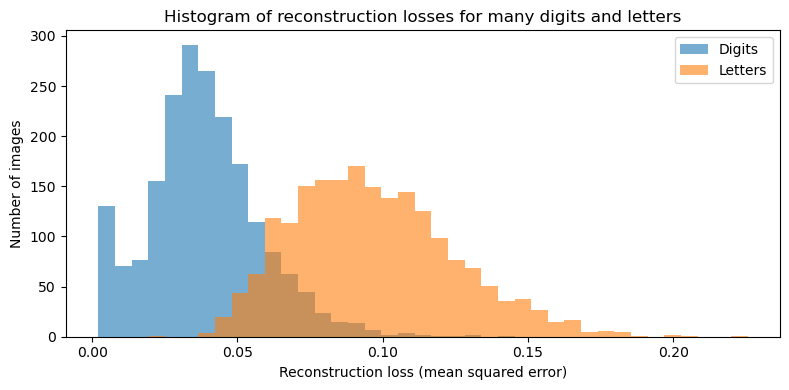

In [35]:
# Plot the two loss distributions on the same axes.
# Overlapping histograms make it easier to see whether letters tend to have higher loss.
plt.figure(figsize=(8, 4))

all_losses = torch.cat([digit_losses, letter_losses]).numpy()
bins = np.linspace(all_losses.min(), all_losses.max(), 40)

plt.hist(digit_losses.numpy(), bins=bins, alpha=0.6, color='tab:blue', label='Digits')
plt.hist(letter_losses.numpy(), bins=bins, alpha=0.6, color='tab:orange', label='Letters')

plt.xlabel('Reconstruction loss (mean squared error)')
plt.ylabel('Number of images')
plt.title('Histogram of reconstruction losses for many digits and letters')
plt.legend()
plt.tight_layout()
plt.show()


## Show original and reconstructed images side by side

The most intuitive view is to place each original image next to its reconstruction.
If the autoencoder has learned the image type well, the reconstruction should look similar to the original.


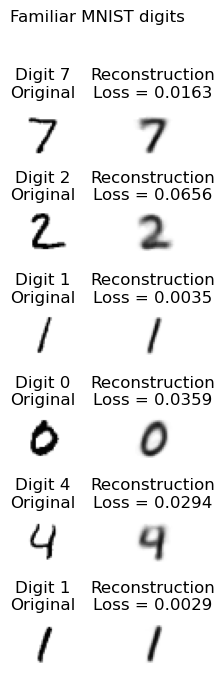

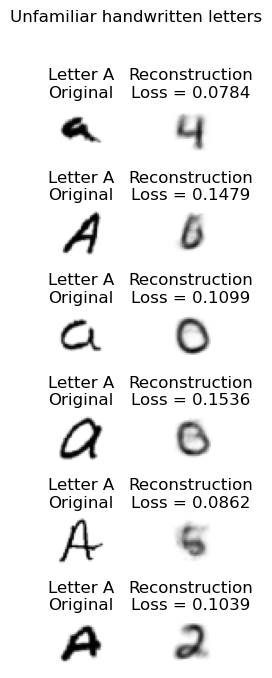

In [36]:
# Helper function: invert the grayscale display so the images appear
# as black writing on a white background.
# This changes only the plot, not the tensor sent into the autoencoder.
def image_for_display(image_tensor):
    return 1.0 - image_tensor.clamp(0.0, 1.0)


# Helper function: show one group of images and their reconstructions.
def plot_original_vs_reconstructed(inputs, reconstructions, losses, text_labels, group_title):
    num_images = inputs.size(0)
    fig, axes = plt.subplots(num_images, 2, figsize=(2.5, 1.1 * num_images))
    fig.suptitle(group_title, y=1.02)

    if num_images == 1:
        axes = np.array([axes])

    for row in range(num_images):
        axes[row, 0].imshow(image_for_display(inputs[row, 0]), cmap='gray', vmin=0.0, vmax=1.0)
        axes[row, 0].set_title(f'{text_labels[row]}\nOriginal')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(image_for_display(reconstructions[row, 0]), cmap='gray', vmin=0.0, vmax=1.0)
        axes[row, 1].set_title(f'Reconstruction\nLoss = {losses[row].item():.4f}')
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()


plot_original_vs_reconstructed(
    digit_inputs,
    digit_recons,
    digit_losses,
    digit_text_labels,
    'Familiar MNIST digits',
)

plot_original_vs_reconstructed(
    letter_inputs,
    letter_recons,
    letter_losses,
    letter_text_labels,
    'Unfamiliar handwritten letters',
)


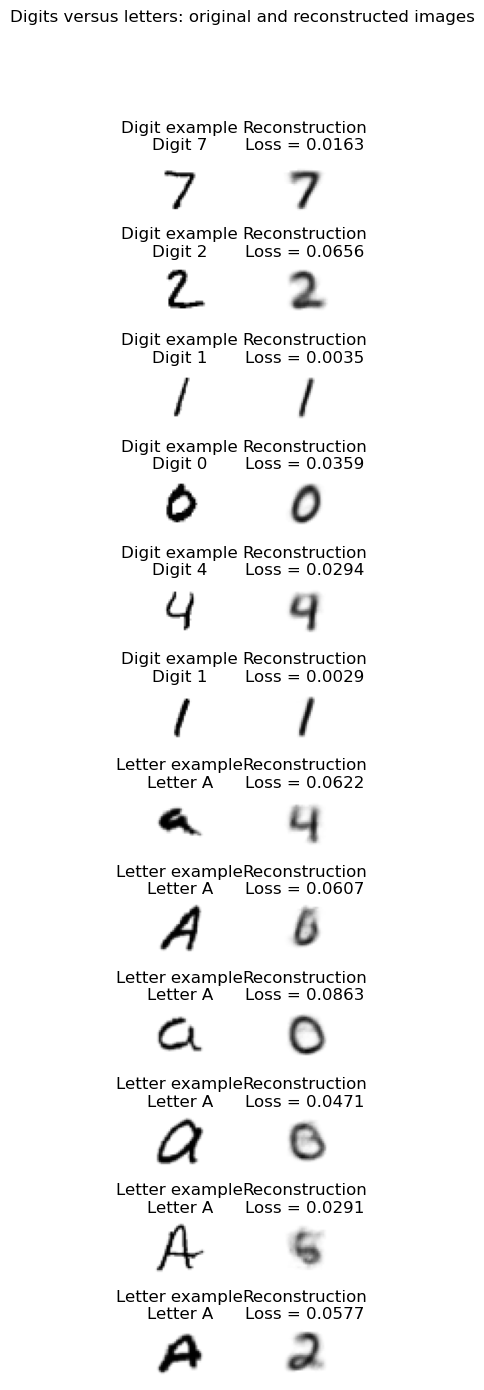

In [37]:
# Put digits and letters into one larger comparison figure.
# This makes the contrast between the two groups easy to discuss in class.
all_inputs = torch.cat([digit_inputs, letter_inputs], dim=0)
all_recons = torch.cat([digit_recons, letter_recons], dim=0)
all_losses = torch.cat([digit_losses, letter_losses], dim=0)
all_text_labels = digit_text_labels + letter_text_labels
all_group_names = ['Digit'] * len(digit_text_labels) + ['Letter'] * len(letter_text_labels)

fig, axes = plt.subplots(len(all_text_labels), 2, figsize=(3, 1.1 * len(all_text_labels)))
fig.suptitle('Digits versus letters: original and reconstructed images', y=1.05)

for row in range(len(all_text_labels)):
    axes[row, 0].imshow(image_for_display(all_inputs[row, 0]), cmap='gray', vmin=0.0, vmax=1.0)
    axes[row, 0].set_title(f'{all_group_names[row]} example\n{all_text_labels[row]}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(image_for_display(all_recons[row, 0]), cmap='gray', vmin=0.0, vmax=1.0)
    axes[row, 1].set_title(f'Reconstruction\nLoss = {all_losses[row].item():.4f}')
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()


## Interpretation

This is the central anomaly-detection idea:

- the autoencoder has learned the structure of the **normal** training examples
- familiar digit images often reconstruct well and give lower loss
- unfamiliar letter images often reconstruct less well and give higher loss

In a real anomaly-detection workflow, we would usually evaluate many examples and choose a threshold on reconstruction loss.
Images with loss above that threshold would be flagged as unusual or anomalous.
